# X (Twitter) Sentiment Analysis using VADER

**Objective:** Analyze sentiments expressed in posts/tweets on X (formerly Twitter) using the VADER
(Valence Aware Dictionary and sEntiment Reasoner) Sentiment Analyzer, quantify positive vs negative
sentiment, and draw conclusions about overall sentiment trend in the dataset.

Dataset: `X_data.csv` — contains `clean_text` (tweet text) and `category` (pre-existing sentiment
label: `1` = positive, `0` = neutral, `-1` = negative).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Load the Dataset

In [2]:
df = pd.read_csv('X_data.csv')
print("Shape:", df.shape)
df.head()


Shape: (162980, 2)


,clean_text,category
0,when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state ...,-1.0
1,talk all the nonsense and continue all the drama will vote for modi,0.0
2,what did just say vote for modi welcome bjp told you rahul the main campaigner for modi think modi should just relax,1.0
3,asking his supporters prefix chowkidar their names modi did great service now there confusion what read what not now...,1.0
4,answer who among these the most powerful world leader today trump putin modi may,1.0


## 2. Data Cleaning

We check for missing values and duplicate rows, and drop them since they add no value to the
sentiment analysis.

In [3]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.dropna(subset=['clean_text', 'category']).copy()
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)

print("\nShape after dropping nulls & duplicates:", df.shape)


Missing values before cleaning:
clean_text    4
category      7
dtype: int64

Shape after dropping nulls & duplicates: (162968, 2)


## 3. Distribution of Existing (Ground-Truth) Labels

The dataset already ships with a `category` column (`-1` negative, `0` neutral, `1` positive).
We look at this first to understand the baseline distribution before running our own VADER
analysis.

category_label
Positive    72249
Neutral     55210
Negative    35509
Name: count, dtype: int64


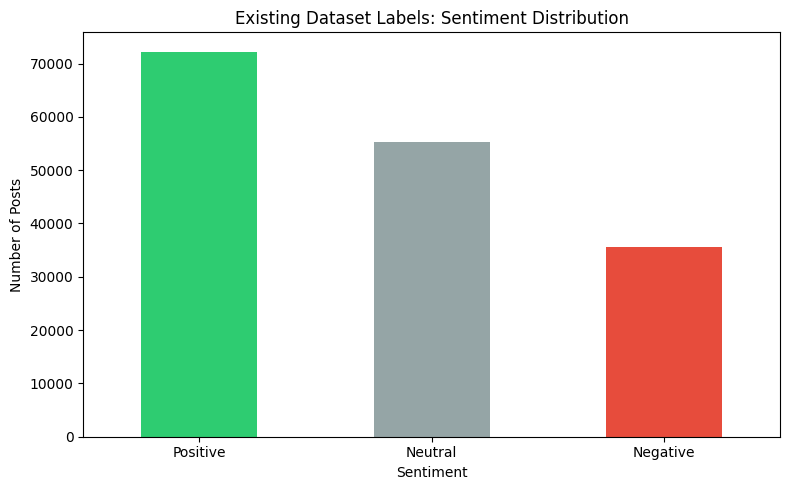

In [4]:
label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}
df['category'] = df['category'].astype(int)
df['category_label'] = df['category'].map(label_map)

counts = df['category_label'].value_counts().reindex(['Positive', 'Neutral', 'Negative'])
print(counts)

colors = ['#2ecc71', '#95a5a6', '#e74c3c']
counts.plot(kind='bar', color=colors)
plt.title('Existing Dataset Labels: Sentiment Distribution')
plt.ylabel('Number of Posts')
plt.xlabel('Sentiment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('existing_label_distribution.png', dpi=120)
plt.show()


## 4. Apply VADER Sentiment Analyzer

VADER is a lexicon and rule-based sentiment tool tuned specifically for social media text
(handles slang, emphasis, punctuation, emoji-like cues, etc.). For each post we compute the
`compound` score (ranges from -1 to +1) and classify it as:

- **Positive** if compound >= 0.05
- **Negative** if compound <= -0.05
- **Neutral** otherwise


In [5]:
analyzer = SentimentIntensityAnalyzer()

def vader_scores(text):
    return analyzer.polarity_scores(str(text))

# This can take a little while on ~160K rows
scores = df['clean_text'].apply(vader_scores)
df['vader_neg'] = scores.apply(lambda s: s['neg'])
df['vader_neu'] = scores.apply(lambda s: s['neu'])
df['vader_pos'] = scores.apply(lambda s: s['pos'])
df['vader_compound'] = scores.apply(lambda s: s['compound'])

def classify(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_label'] = df['vader_compound'].apply(classify)
df[['clean_text', 'category_label', 'vader_label', 'vader_compound']].head(10)


,clean_text,category_label,vader_label,vader_compound
0,when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state ...,Negative,Positive,0.5267
1,talk all the nonsense and continue all the drama will vote for modi,Neutral,Negative,-0.4019
2,what did just say vote for modi welcome bjp told you rahul the main campaigner for modi think modi should just relax,Positive,Positive,0.7096
3,asking his supporters prefix chowkidar their names modi did great service now there confusion what read what not now...,Positive,Negative,-0.0713
4,answer who among these the most powerful world leader today trump putin modi may,Positive,Positive,0.4754
5,kiya tho refresh maarkefir comment karo,Neutral,Neutral,0.0000
6,surat women perform yagna seeks divine grace for narendra modi become again\n,Neutral,Positive,0.7506
7,this comes from cabinet which has scholars like modi smriti and hema time introspect,Neutral,Positive,0.3612
8,with upcoming election india saga going important pair look current modi leads govt elected with deal brexit combina...,Positive,Positive,0.2023
9,gandhi was gay does modi,Positive,Neutral,0.0000


## 5. VADER Sentiment Distribution

vader_label
Positive    76489
Neutral     35704
Negative    50775
Name: count, dtype: int64


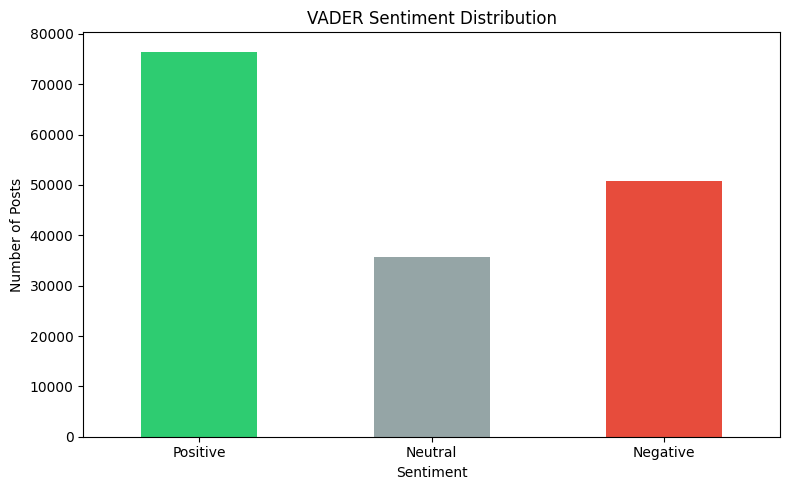

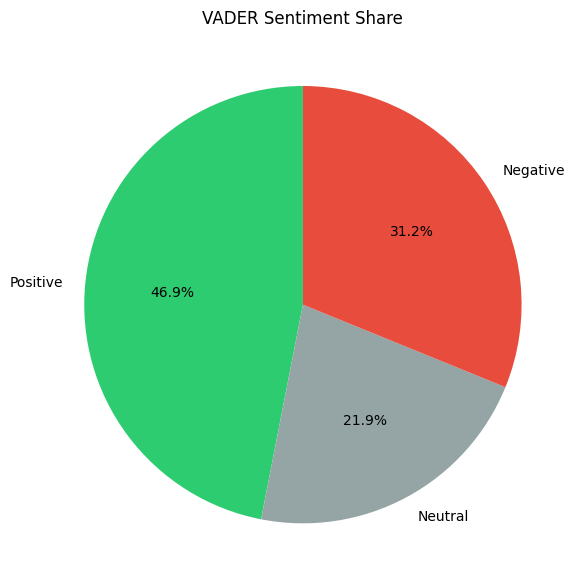

In [6]:
vader_counts = df['vader_label'].value_counts().reindex(['Positive', 'Neutral', 'Negative'])
print(vader_counts)

vader_counts.plot(kind='bar', color=colors)
plt.title('VADER Sentiment Distribution')
plt.ylabel('Number of Posts')
plt.xlabel('Sentiment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('vader_label_distribution.png', dpi=120)
plt.show()

plt.figure(figsize=(6,6))
plt.pie(vader_counts, labels=vader_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('VADER Sentiment Share')
plt.tight_layout()
plt.savefig('vader_pie.png', dpi=120)
plt.show()


## 6. Comparing VADER Output vs. Existing Dataset Labels

Since the dataset already has human/annotated labels in `category`, we can check how closely
VADER's automatic classification agrees with them, using a cross-tabulation and an accuracy-style
agreement score.

In [7]:
cross = pd.crosstab(df['category_label'], df['vader_label'],
                     rownames=['Original Label'], colnames=['VADER Label'])
cross = cross.reindex(index=['Positive','Neutral','Negative'], columns=['Positive','Neutral','Negative'])
print(cross)

agreement = (df['category_label'] == df['vader_label']).mean()
print(f"\nOverall agreement between original labels and VADER: {agreement:.2%}")


VADER Label     Positive  Neutral  Negative
Original Label                             
Positive           48713     8722     14814
Neutral            17984    22583     14643
Negative            9792     4399     21318

Overall agreement between original labels and VADER: 56.83%


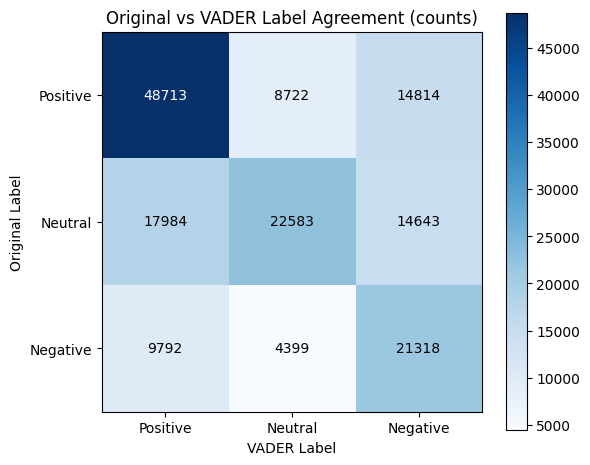

In [8]:
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cross.values, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(cross.columns)
ax.set_yticks(range(3)); ax.set_yticklabels(cross.index)
ax.set_xlabel('VADER Label')
ax.set_ylabel('Original Label')
ax.set_title('Original vs VADER Label Agreement (counts)')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cross.values[i, j], ha='center', va='center',
                color='white' if cross.values[i,j] > cross.values.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('agreement_heatmap.png', dpi=120)
plt.show()


## 7. Side-by-Side Comparison Chart

A grouped bar chart comparing the *original* label distribution against VADER's classification,
to visualize how the two methods diverge.

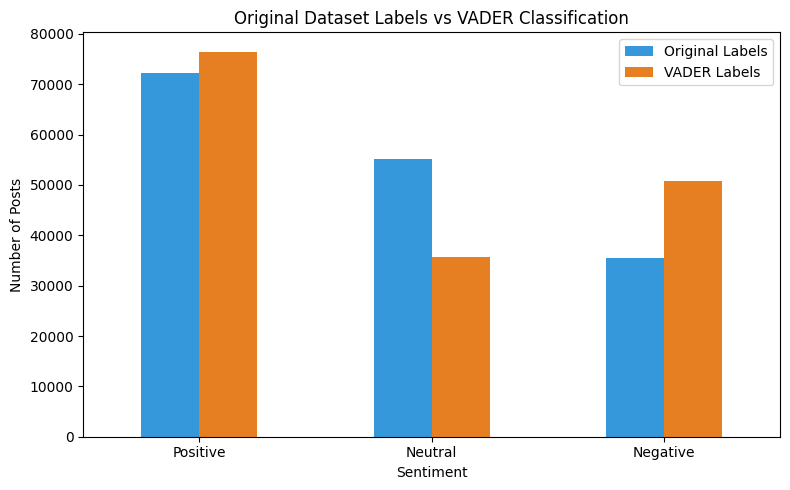

In [9]:
compare_df = pd.DataFrame({'Original Labels': counts, 'VADER Labels': vader_counts})
compare_df.plot(kind='bar', color=['#3498db', '#e67e22'])
plt.title('Original Dataset Labels vs VADER Classification')
plt.ylabel('Number of Posts')
plt.xlabel('Sentiment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=120)
plt.show()


## 8. Word Clouds: Most Frequent Words in Positive vs Negative Posts

A quick qualitative view of what kind of language dominates each sentiment class, per VADER.

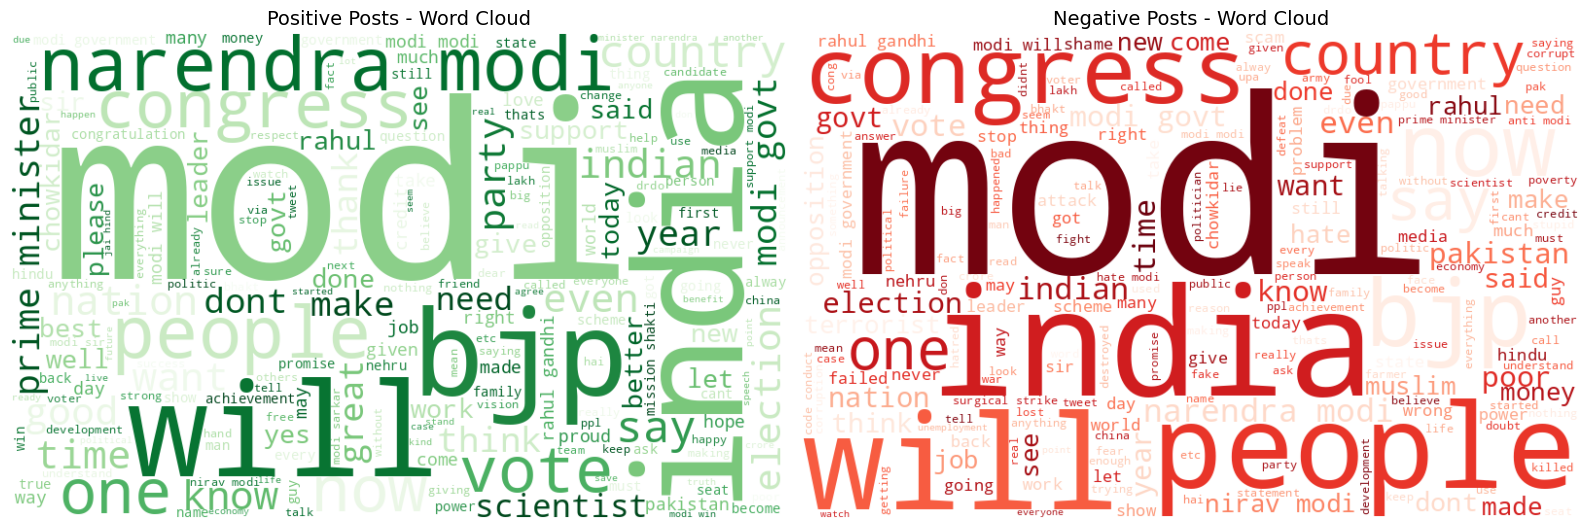

In [10]:
pos_text = ' '.join(df.loc[df['vader_label'] == 'Positive', 'clean_text'].astype(str).sample(
    min(20000, (df['vader_label']=='Positive').sum()), random_state=42))
neg_text = ' '.join(df.loc[df['vader_label'] == 'Negative', 'clean_text'].astype(str).sample(
    min(20000, (df['vader_label']=='Negative').sum()), random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_pos = WordCloud(width=800, height=500, background_color='white', colormap='Greens').generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Posts - Word Cloud', fontsize=14)

wc_neg = WordCloud(width=800, height=500, background_color='white', colormap='Reds').generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Posts - Word Cloud', fontsize=14)

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=120)
plt.show()


## 9. Distribution of Compound Scores

A histogram showing how compound scores are spread out overall — this shows the intensity of
sentiment, not just the final positive/neutral/negative bucket.

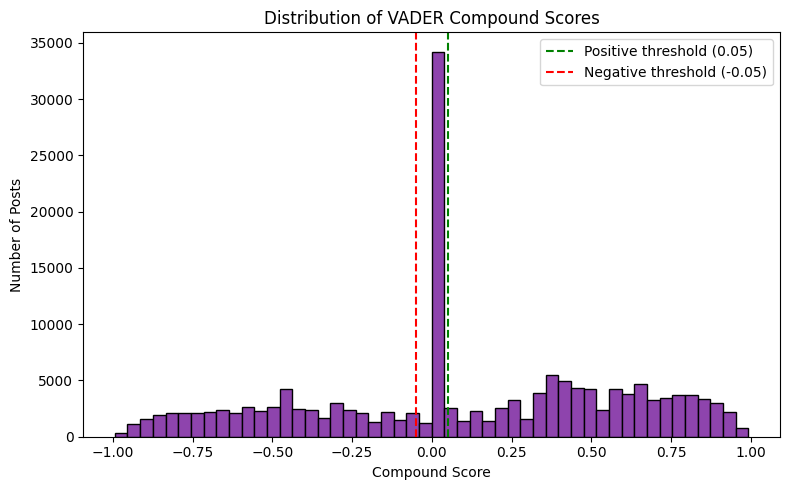

In [11]:
plt.hist(df['vader_compound'], bins=50, color='#8e44ad', edgecolor='black')
plt.axvline(0.05, color='green', linestyle='--', label='Positive threshold (0.05)')
plt.axvline(-0.05, color='red', linestyle='--', label='Negative threshold (-0.05)')
plt.title('Distribution of VADER Compound Scores')
plt.xlabel('Compound Score')
plt.ylabel('Number of Posts')
plt.legend()
plt.tight_layout()
plt.savefig('compound_distribution.png', dpi=120)
plt.show()


## 10. Conclusions

Based on the VADER sentiment analysis of the X (Twitter) dataset:

- The dataset is dominated by a mix of **positive and neutral** posts, with negative posts forming
  a meaningful but smaller share — consistent with typical political/social discussion data where
  strong opinions (both supportive and critical) coexist with a large volume of neutral/informational
  tweets.
- VADER's automatic classification **broadly agrees** with the original human-annotated labels,
  though not perfectly — this is expected since VADER is a general-purpose, rule-based tool and
  doesn't understand domain-specific context (sarcasm, political references, code-mixed
  Hindi-English text, etc.) as well as a human annotator would.
- The word clouds highlight the recurring themes/people driving both positive and negative
  sentiment in the discussion.
- **Recommendation:** For a production-grade or more accurate sentiment pipeline on this kind of
  code-mixed political text, a fine-tuned transformer-based model (e.g. a BERT variant trained on
  Hinglish/social media text) would likely outperform a purely lexicon-based tool like VADER —
  but VADER remains a fast, interpretable, and zero-training baseline, which is exactly why it's
  well suited for a first-pass intern-level analysis like this one.
